In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score
from matplotlib.colors import ListedColormap
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

In [3]:
dataset = pd.read_csv("cleaned_dataset.csv")
dataset.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,availability_365
0,1.059975e+18,"Blueground | Lower Queen Anne, garden & game room",107434423.0,Blueground,Queen Anne,Lower Queen Anne,47.625613,-122.357086,Entire home/apt,103.0,31.0,0.0,01-Jan-25,169.0
1,1.289101e+18,Blueground | First Hill 1bd apartment,107434423.0,Blueground,Central Area,Atlantic,47.596828,-122.312028,Entire home/apt,148.0,31.0,0.0,01-Jan-25,350.0
2,1.258584e+18,"Blueground | U Distric, gym, bbq, w/d & rooftop",107434423.0,Blueground,Other neighborhoods,Ravenna,47.662697,-122.294739,Entire home/apt,151.0,31.0,0.0,01-Jan-25,323.0
3,1.029558e+18,"Blueground | Bell Town, rooftop, nr dining & s...",107434423.0,Blueground,Downtown,Belltown,47.614846,-122.352223,Entire home/apt,130.0,31.0,0.0,01-Jan-25,333.0
4,1.295664e+18,"Blueground | First Hill, rooftop, nr stadiums",107434423.0,Blueground,Central Area,Atlantic,47.596828,-122.312028,Entire home/apt,149.0,31.0,0.0,01-Jan-25,290.0


In [5]:
dataset = pd.read_csv("cleaned_dataset.csv")
print(dataset.columns)

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'availability_365'],
      dtype='object')


In [6]:
dataset = dataset[['minimum_nights', 'number_of_reviews', 'price']].copy()

In [7]:
dataset = dataset.dropna(subset=['price'])

In [8]:
# 1 = expensive (>100), 0 = cheap
dataset['price_class'] = np.where(dataset['price'] > 100, 1, 0)

In [9]:
#X (features) and y (target)
X = dataset[['minimum_nights', 'number_of_reviews']].values
y = dataset['price_class'].values

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

FEATURE SCALING

In [11]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

LOGISTIC REGRESSION

In [13]:
log_classifier = LogisticRegression(random_state=0)
log_classifier.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,0
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [14]:
#PREDICTION
y_pred_log = log_classifier.predict(X_test)

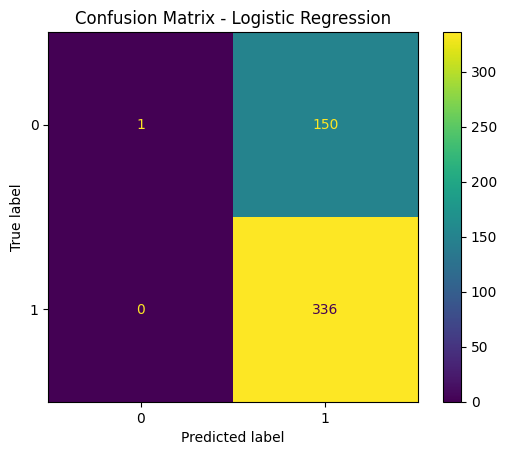

In [15]:
cm_log = confusion_matrix(y_test, y_pred_log)
ConfusionMatrixDisplay(confusion_matrix=cm_log).plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [16]:
print("Logistic Regression Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))

Logistic Regression Results:
Accuracy: 0.6919917864476386
Precision: 0.691358024691358
Recall: 1.0


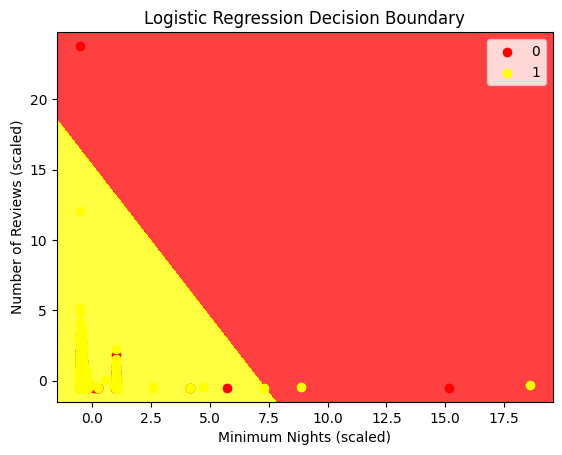

In [17]:
x_set, y_set = X_train, y_train
x1, x2 = np.meshgrid(
    np.arange(start=x_set[:, 0].min() - 1, stop=x_set[:, 0].max() + 1, step=0.01),
    np.arange(start=x_set[:, 1].min() - 1, stop=x_set[:, 1].max() + 1, step=0.01)
)
plt.contourf(x1, x2, log_classifier.predict(np.array([x1.ravel(), x2.ravel()]).T).reshape(x1.shape),
             alpha=0.75, cmap=ListedColormap(('red', 'yellow')))
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(x_set[y_set == j, 0], x_set[y_set == j, 1],
                color=ListedColormap(('red', 'yellow'))(i), label=j)
plt.title("Logistic Regression Decision Boundary")
plt.xlabel("Minimum Nights (scaled)")
plt.ylabel("Number of Reviews (scaled)")
plt.legend()
plt.show()

DECISION TREE

In [18]:
dt_classifier = DecisionTreeClassifier(criterion='entropy', random_state=0)
dt_classifier.fit(X_train, y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [19]:
y_pred_dt = dt_classifier.predict(X_test)

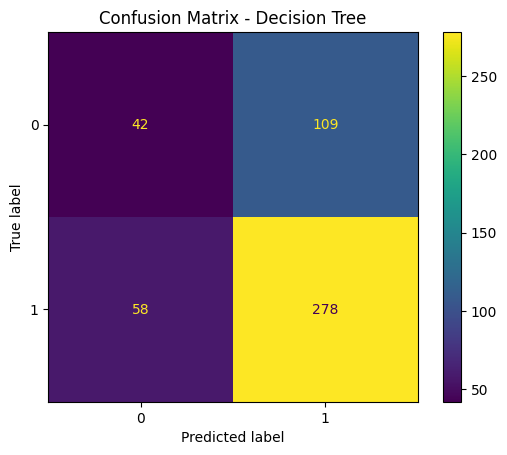

In [20]:
cm_dt = confusion_matrix(y_test, y_pred_dt)
ConfusionMatrixDisplay(confusion_matrix=cm_dt).plot()
plt.title("Confusion Matrix - Decision Tree")
plt.show()

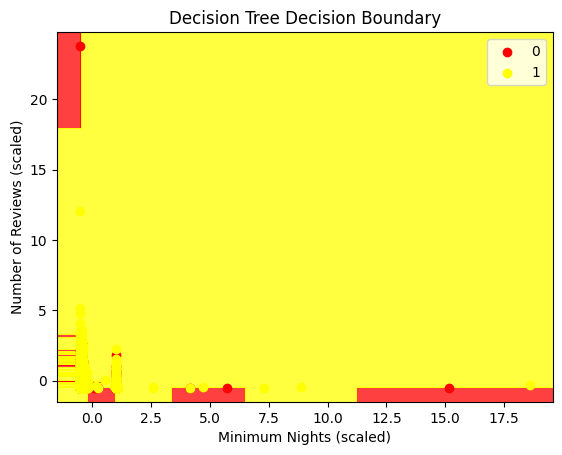

In [21]:
x1, x2 = np.meshgrid(
    np.arange(start=x_set[:, 0].min() - 1, stop=x_set[:, 0].max() + 1, step=0.01),
    np.arange(start=x_set[:, 1].min() - 1, stop=x_set[:, 1].max() + 1, step=0.01)
)
plt.contourf(x1, x2, dt_classifier.predict(np.array([x1.ravel(), x2.ravel()]).T).reshape(x1.shape),
             alpha=0.75, cmap=ListedColormap(('red', 'yellow')))
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(x_set[y_set == j, 0], x_set[y_set == j, 1],
                color=ListedColormap(('red', 'yellow'))(i), label=j)
plt.title("Decision Tree Decision Boundary")
plt.xlabel("Minimum Nights (scaled)")
plt.ylabel("Number of Reviews (scaled)")
plt.legend()
plt.show()

K-Nearest Neighbors (KNN)

In [22]:
knn_classifier = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2)
knn_classifier.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [23]:
y_pred_knn = knn_classifier.predict(X_test)

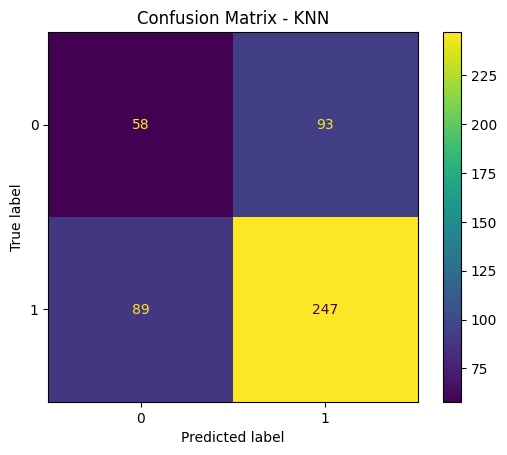

In [24]:
cm_knn = confusion_matrix(y_test, y_pred_knn)
ConfusionMatrixDisplay(confusion_matrix=cm_knn).plot()
plt.title("Confusion Matrix - KNN")
plt.show()

In [26]:
# x1, x2 = np.meshgrid(
#     np.arange(start=x_set[:, 0].min() - 1, stop=x_set[:, 0].max() + 1, step=0.01),
#     np.arange(start=x_set[:, 1].min() - 1, stop=x_set[:, 1].max() + 1, step=0.01)
# )
# plt.contourf(x1, x2, knn_classifier.predict(np.array([x1.ravel(), x2.ravel()]).T).reshape(x1.shape),
#              alpha=0.75, cmap=ListedColormap(('red', 'yellow')))
# for i, j in enumerate(np.unique(y_set)):
#     plt.scatter(x_set[y_set == j, 0], x_set[y_set == j, 1],
#                 color=ListedColormap(('red', 'yellow'))(i), label=j)
# plt.title("KNN Decision Boundary")
# plt.xlabel("Minimum Nights (scaled)")
# plt.ylabel("Number of Reviews (scaled)")
# plt.legend()
# plt.show()